# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

### IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F


import pygame
_ = pygame.init()


print("✅ Tutto importato con successo!")
print(f"-> Versione PyTorch: {torch.__version__}")
print(f"-> Versione Gymnasium: {gym.__version__}")
print(f"-> Versione NumPy: {np.__version__}")
print(f"-> La GPU (CUDA) è attiva? {torch.cuda.is_available()}")

✅ Tutto importato con successo!
-> Versione PyTorch: 2.12.0+cu130
-> Versione Gymnasium: 1.3.0
-> Versione NumPy: 2.2.5
-> La GPU (CUDA) è attiva? True


### Code to TEST how long it lasts when choosing **randomly**

In [16]:
# Instantiate a rendering and a non-rendering environment.
env = gym.make('CartPole-v1', render_mode='human')
#env = gym.make('CartPole-v1')

In [17]:

# Inspect the environment's spaces & bounds
print(" Environment Inspection")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")
print(f"Observation Bounds (Low): {env.observation_space.low}")
print(f"Observation Bounds (High): {env.observation_space.high}\n")

# Reset and check initial state
initial_obs, reset_info = env.reset()
print(f"-> Initial Observation: {initial_obs}")
print(f"-> Reset Info: {reset_info}\n")

# Run a few random episodes to "explore" the dynamics
print("-> Running 3 random episodes for exploration")
for ep in range(10):
    obs, _ = env.reset()
    total_reward = 0.0
    step = 0
    done = False
    
    while not done:
        action = env.action_space.sample()  # Uniform random action
        next_obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        step += 1
        done = terminated or truncated
        
        # Print first few steps of the first episode for clarity
        if ep == 0 and step <= 5:
            print(f"  Step {step:2d} | Action: {action} | Reward: {reward:.1f} | "
                  f"Pos: {next_obs[0]:.3f} | Vel: {next_obs[1]:.3f} | "
                  f"Angle: {next_obs[2]:.3f} | AngVel: {next_obs[3]:.3f} | "
                  f"Terminated: {terminated} | Truncated: {truncated}")
                  
    print(f"Episode {ep+1:2d} | Length: {step:3d} | Total Reward: {total_reward:.1f}")

print("\n✅ Environment exploration complete.")
env.close()

 Environment Inspection
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)
Observation Bounds (Low): [-4.8               -inf -0.41887903        -inf]
Observation Bounds (High): [4.8               inf 0.41887903        inf]

-> Initial Observation: [-0.04818054  0.00525864  0.02025365 -0.04052325]
-> Reset Info: {}

-> Running 3 random episodes for exploration
  Step  1 | Action: 0 | Reward: 1.0 | Pos: 0.005 | Vel: -0.223 | Angle: 0.040 | AngVel: 0.345 | Terminated: False | Truncated: False
  Step  2 | Action: 1 | Reward: 1.0 | Pos: 0.000 | Vel: -0.028 | Angle: 0.047 | AngVel: 0.066 | Terminated: False | Truncated: False
  Step  3 | Action: 1 | Reward: 1.0 | Pos: -0.000 | Vel: 0.166 | Angle: 0.048 | AngVel: -0.212 | Terminated: False | Truncated: False
  Step  4 | Action: 1 | Reward: 1.0 | Pos: 0.003 | Vel: 0.361 | Angle: 0.044 | AngVel: -0.489 | Terminated: False | Truncated:

### CartPole ha uno spazio di osservazione continuo a 4 dimensioni (posizione carrello, velocità, angolo palo, velocità angolare) e solo 2 azioni discrete (sinistra/destra). Un agente completamente random regge in media meno di 20 step: questo stabilisce la baseline da battere. Il reward è +1 per ogni step in cui il palo rimane in piedi; il massimo teorico è 500.

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

### **IMPORTING** the package where I put all the used function for RL training

In [2]:
from drl_lab.networks import PolicyNetwork, ValueNetwork
from drl_lab.algorithms import reinforce, run_episode
from drl_lab.evaluation import evaluate_policy

In [ ]:
#test

policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)

env_render = gym.make('CartPole-v1', render_mode='human')
for _ in range(10):
    run_episode(env_render, policy, device="cpu")
env_render.close()

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

### **FIRST RUN WITH WANDB LOGGING**: I implemenmted the new evaluation method proposed above along with **OmegaConf** enviroment setting parameters and with consequent **Wandb** initialization of run and logging.

In [3]:
import os
os.environ["SDL_AUDIODRIVER"] = "dummy"

import wandb
import omegaconf
from omegaconf import OmegaConf

cfg = OmegaConf.load("config_base.yaml")

seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)

policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)


### **WANDB** run initialization

In [9]:
wandb.init(
    project=cfg.experiment.project,
    name=cfg.experiment.name,
    config=OmegaConf.to_container(cfg, resolve=True)
)

In [7]:
# Train with robust evaluation
history = reinforce(
    policy=policy,
    env=env,
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=True,  
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Ep    0] Train:   31.0 | Eval:    9.5
   💾 New best model saved!
[Ep   50] Train:   19.0 | Eval:   34.2
   💾 New best model saved!
[Ep  100] Train:  370.0 | Eval:  358.5
   💾 New best model saved!
[Ep  150] Train:  153.0 | Eval:  165.7
[Ep  200] Train:  104.0 | Eval:   99.3
[Ep  250] Train:  500.0 | Eval:  500.0
   💾 New best model saved!
[Ep  300] Train:  500.0 | Eval:  500.0
[Ep  350] Train:  500.0 | Eval:  500.0
[Ep  400] Train:  500.0 | Eval:  500.0
[Ep  450] Train:  119.0 | Eval:  102.3
[Ep  500] Train:  500.0 | Eval:  495.4
[Ep  550] Train:  500.0 | Eval:  500.0
[Ep  600] Train:  500.0 | Eval:  500.0
[Ep  650] Train:  500.0 | Eval:  500.0
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  500.0 | Eval:  500.0
[Ep  800] Train:  500.0 | Eval:  500.0
[Ep  850] Train:  500.0 | Eval:  500.0
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▁▆▃▂████▂██████████
eval/avg_reward,▁▁▆▃▂████▂██████████
train/actor_loss,▁▆▃▅▆▃█▆▅▅▆▇▇▅▅▅▇▇▇▅▅▅▆▅▇▄▇▅█▅▅▆▆▆▅▅▆▇▄▆
train/episode_reward,▁▁▁▂▂▃▃▂███▇██████▁▁▂▄████▆████▅███████▇
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,0.00969
train/episode_reward,500


### **PLOTTING** results

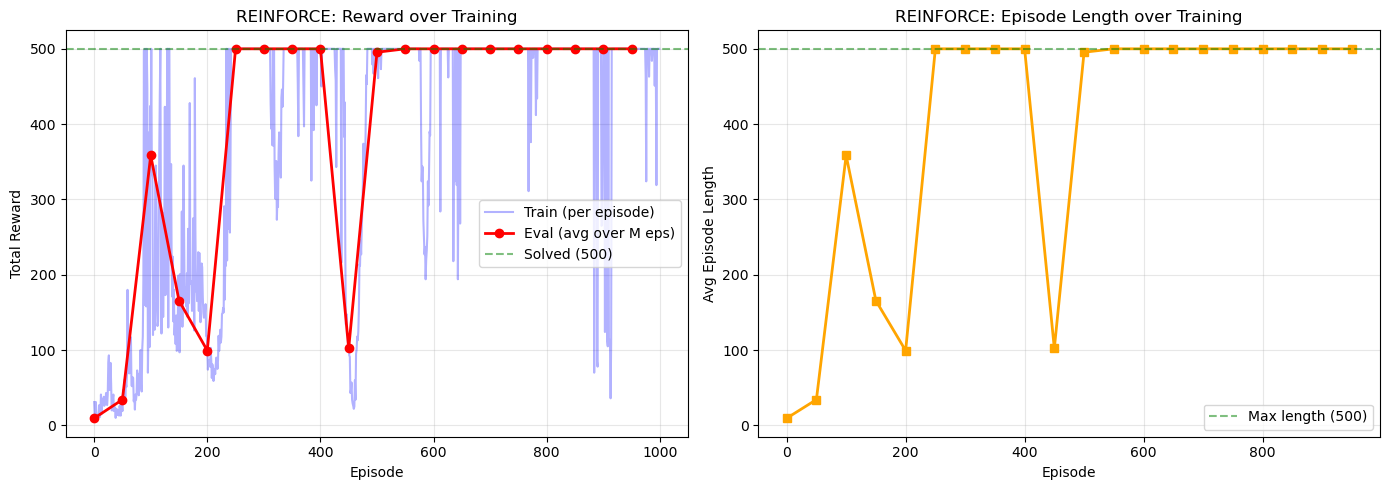

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **VISUAL** Test

In [ ]:
os.environ["SDL_AUDIODRIVER"] = "dummy" # Per evitare warning audio su Kaggle/Linux

# 1. Setup ambiente di rendering
env_render = gym.make('CartPole-v1', render_mode='human')
pygame.display.init()

# 2. Metti la policy in modalità valutazione (anche se qui non cambia molto i pesi)
policy.eval()

# 3. Loop di visualizzazione DETERMINISTICA (Greedy)
with torch.no_grad(): # Disabilita il calcolo dei gradienti per velocità
    obs, _ = env_render.reset()
    done = False
    
    while not done:
        obs_tensor = torch.from_numpy(obs).float().unsqueeze(0).to(device)
        
        # --- IL TRUCCO: Argmax invece di Sample ---
        probs = policy(obs_tensor)
        action = torch.argmax(probs, dim=-1).item() # Scegli sempre la migliore!
        # ------------------------------------------
        
        obs, reward, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated
        
        # Pausa leggera per rendere la visualizzazione godibile (opzionale)
        pygame.time.wait(10) 

env_render.close()
pygame.display.quit()
print("Visualizzazione completata!")

-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



### **SETUP**

In [3]:
import os
os.environ["SDL_AUDIODRIVER"] = "dummy"

import wandb
import omegaconf
from omegaconf import OmegaConf

cfg = OmegaConf.load("config_base.yaml")

seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)

policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)


In [4]:
wandb.init(
    project=cfg.experiment.project,
    name=cfg.experiment.name,
    config=OmegaConf.to_container(cfg, resolve=True)
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/tomma/.netrc.


wandb: Currently logged in as: tommypasto (Tommy_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

### **RUNS WITH and WITHOUT STANDARDIZATION**

#### I'm going to try different values of learning rate to see how learning varies in all cases.

In [8]:
"""
seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)
"""

# LETS USE A HIGHER LR (1e-2)

history = reinforce(
    policy=policy,
    env=env,
    lr=1e-2,          
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=False,  
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Ep    0] Train:   31.0 | Eval:   12.8
   💾 New best model saved!
[Ep   50] Train:   52.0 | Eval:  151.0
   💾 New best model saved!
[Ep  100] Train:  110.0 | Eval:  123.6
[Ep  150] Train:   24.0 | Eval:   26.7
[Ep  200] Train:   13.0 | Eval:   11.7
[Ep  250] Train:   28.0 | Eval:   32.5
[Ep  300] Train:   15.0 | Eval:   13.7
[Ep  350] Train:   11.0 | Eval:    9.8
[Ep  400] Train:   12.0 | Eval:   11.8
[Ep  450] Train:  120.0 | Eval:  133.1
[Ep  500] Train:  500.0 | Eval:  500.0
   💾 New best model saved!
[Ep  550] Train:   25.0 | Eval:  116.8
[Ep  600] Train:   38.0 | Eval:   29.7
[Ep  650] Train:  108.0 | Eval:  111.0
[Ep  700] Train:  121.0 | Eval:  129.6
[Ep  750] Train:  406.0 | Eval:  447.1
[Ep  800] Train:  500.0 | Eval:  500.0
[Ep  850] Train:   10.0 | Eval:   54.8
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▃▃▁▁▁▁▁▁▃█▃▁▂▃▇█▂██
eval/avg_reward,▁▃▃▁▁▁▁▁▁▃█▃▁▂▃▇█▂██
train/actor_loss,▂▄▂▃▄▂▁▁▁▁▂▂▂▂▁▁▁▁▂▇▆▇▇█▂▃▄▂▄▄█▇▇▁▅▆▆▆▆▅
train/episode_reward,▁▁▃▄▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁██▁▁▁▂▃▄████▁▃██████
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,22.83631
train/episode_reward,500


### **PLOTTING** results

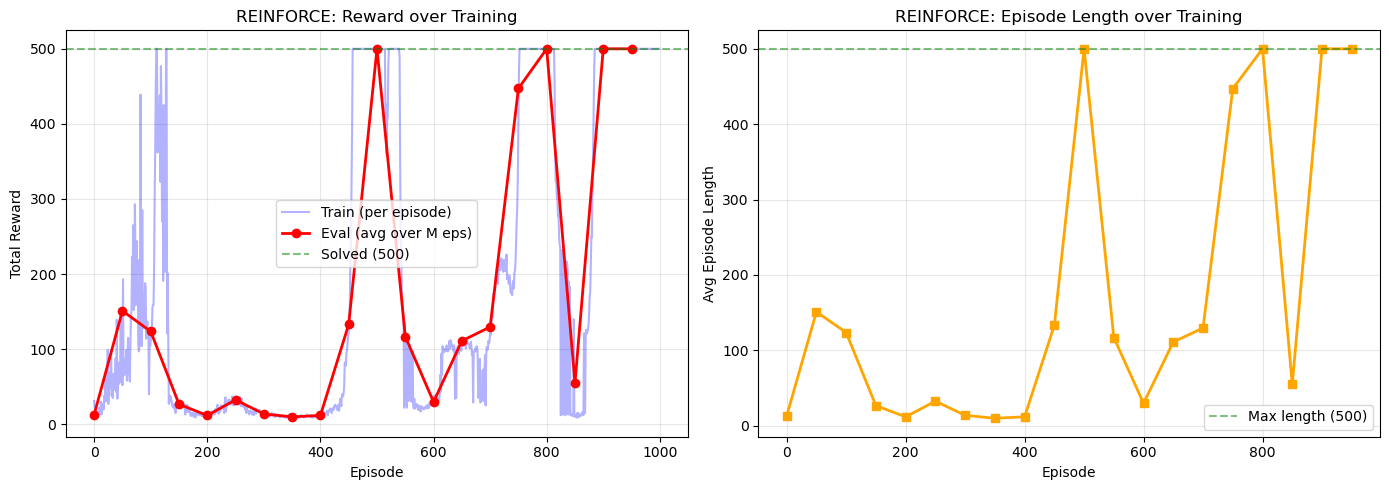

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **REINFORCE senza standardizzazione, lr=1e-2:** il modello raggiunge un picco di ~150 a ep 50 poi collassa e non si riprende. Con lr alto e ritorni non normalizzati, gli aggiornamenti del gradiente sono troppo grandi e instabili: il policy network diverge invece di convergere. Questo è il comportamento tipico di REINFORCE ad alta varianza.

In [13]:
# Your code here. Modify your implementation of `REINFORCE` to optionally use the standardize baseline.

"""
seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)
"""

# LETS USE A LOWER LR (3e-3)

history = reinforce(
    policy=policy,
    env=env,
    lr=3e-3,          
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=False,  
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Ep    0] Train:   31.0 | Eval:    9.5
   💾 New best model saved!
[Ep   50] Train:   30.0 | Eval:   45.3
   💾 New best model saved!
[Ep  100] Train:   34.0 | Eval:   91.5
   💾 New best model saved!
[Ep  150] Train:  111.0 | Eval:  337.9
   💾 New best model saved!
[Ep  200] Train:   38.0 | Eval:   34.0
[Ep  250] Train:   62.0 | Eval:   52.3
[Ep  300] Train:  118.0 | Eval:  133.4
[Ep  350] Train:   34.0 | Eval:   72.2
[Ep  400] Train:   70.0 | Eval:   90.2
[Ep  450] Train:  500.0 | Eval:  500.0
   💾 New best model saved!
[Ep  500] Train:  345.0 | Eval:  361.3
[Ep  550] Train:  154.0 | Eval:  226.0
[Ep  600] Train:  125.0 | Eval:  128.0
[Ep  650] Train:  280.0 | Eval:  327.6
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  162.0 | Eval:  187.7
[Ep  800] Train:   73.0 | Eval:   99.7
[Ep  850] Train:  385.0 | Eval:  432.7
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▂▂▆▁▂▃▂▂█▆▄▃▆█▄▂▇██
eval/avg_reward,▁▂▂▆▁▂▃▂▂█▆▄▃▆█▄▂▇██
train/actor_loss,▁▂▂▂▁▂▄▅▂▁▁▂▂▂▃██▅▁▅▅▄▄▇▇▇▅▅▄▅▅▇▇▇▇▇▇▇▇▇
train/episode_reward,▁▁▂▁▁▃▂▃▂▁▁▁▂▂▂███▇▃▄▃▂▃▄▅███▂▃▃▄▇██████
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,40.69533
train/episode_reward,500


### **PLOTTING** results

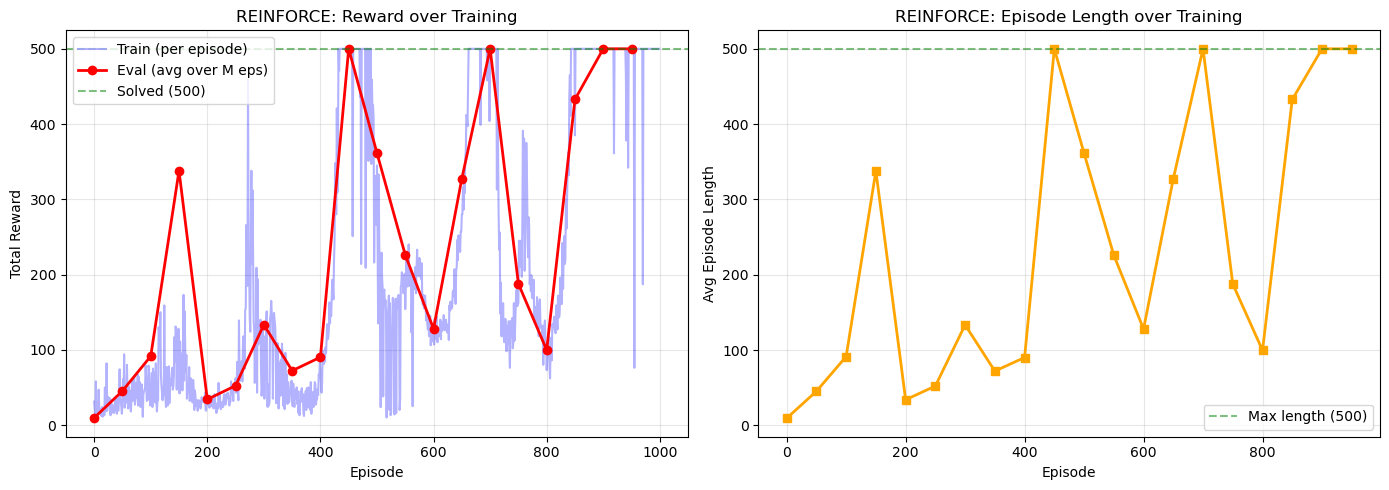

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **REINFORCE senza standardizzazione, lr=3e-3:** lr più basso sembra alleggerire leggermente il collasso ma non lo risolve.Il modello oscilla senza convergere stabilmente. 

In [17]:
"""
seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)
"""

history = reinforce(
    policy=policy,
    env=env,
    lr=1e-2,          
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=True,  
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Ep    0] Train:   31.0 | Eval:    9.5
   💾 New best model saved!
[Ep   50] Train:   19.0 | Eval:   34.2
   💾 New best model saved!
[Ep  100] Train:  370.0 | Eval:  358.5
   💾 New best model saved!
[Ep  150] Train:  153.0 | Eval:  165.7
[Ep  200] Train:  104.0 | Eval:   99.3
[Ep  250] Train:  500.0 | Eval:  500.0
   💾 New best model saved!
[Ep  300] Train:  500.0 | Eval:  500.0
[Ep  350] Train:  500.0 | Eval:  500.0
[Ep  400] Train:  500.0 | Eval:  500.0
[Ep  450] Train:  119.0 | Eval:  102.3
[Ep  500] Train:  500.0 | Eval:  495.4
[Ep  550] Train:  500.0 | Eval:  500.0
[Ep  600] Train:  500.0 | Eval:  500.0
[Ep  650] Train:  500.0 | Eval:  500.0
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  500.0 | Eval:  500.0
[Ep  800] Train:  500.0 | Eval:  500.0
[Ep  850] Train:  500.0 | Eval:  500.0
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▁▆▃▂████▂██████████
eval/avg_reward,▁▁▆▃▂████▂██████████
train/actor_loss,▅█▄▅▁▄▅▅▆▅▅▅▅▆▅▆▅▅▅▄▅▅▆▅▅▅▅▅▅▅▅▆▅▅▅▆▅▅▅▆
train/episode_reward,▁▁▁▁▁▂█▆▇▃▂▂██▇██▇▆▃▁▇███▄▅▆██████████▇█
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,0.00969
train/episode_reward,500


### **PLOTTING** results

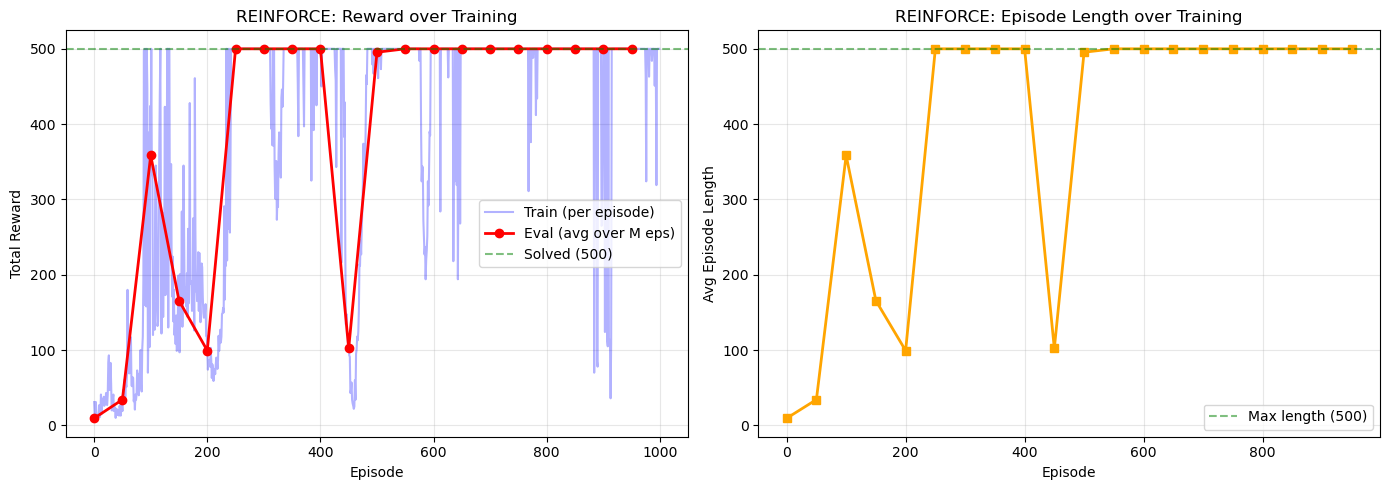

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **REINFORCE + standardizzazione, lr=1e-2:** Il modello si dimostra molto più capace di raggiungere reward massimo, anche se con due grossi cali a picco intorno agli episodi 200 e 450. La standardizzazione dei ritorni normalizza la scala dei gradienti ad ogni episodio, riducendo la varianza degli aggiornamenti e accelerando la convergenza rispetto al REINFORCE puro.

In [21]:
# Your code here. Modify your implementation of `REINFORCE` to optionally use the standardize baseline.
"""
seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cpu")
env = gym.make('CartPole-v1')
env.reset(seed=seed)
"""

#Best LR: 1e-2


history = reinforce(
    policy=policy,
    env=env,
    lr=3e-3,          
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=True,  
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


[Ep    0] Train:   31.0 | Eval:    9.5
   💾 New best model saved!
[Ep   50] Train:   19.0 | Eval:    9.3
[Ep  100] Train:   54.0 | Eval:   91.7
   💾 New best model saved!
[Ep  150] Train:   57.0 | Eval:  500.0
   💾 New best model saved!
[Ep  200] Train:   81.0 | Eval:  129.6
[Ep  250] Train:  500.0 | Eval:  492.1
[Ep  300] Train:  339.0 | Eval:  465.1
[Ep  350] Train:  497.0 | Eval:  499.9
[Ep  400] Train:  500.0 | Eval:  500.0
[Ep  450] Train:  500.0 | Eval:  500.0
[Ep  500] Train:  500.0 | Eval:  500.0
[Ep  550] Train:  500.0 | Eval:  500.0
[Ep  600] Train:  361.0 | Eval:  306.9
[Ep  650] Train:  500.0 | Eval:  473.6
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  500.0 | Eval:  500.0
[Ep  800] Train:  271.0 | Eval:  500.0
[Ep  850] Train:  500.0 | Eval:  500.0
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▁▂█▃███████▅███████
eval/avg_reward,▁▁▂█▃███████▅███████
train/actor_loss,█▅▃▇▅▃▄▅▅▁▅▄▄▄▅▄▄▅▅▅▅▅▅▄▅▄▅▅▅▅▄▅▅▄▅▅▅▅▄▅
train/episode_reward,▁▁▂▁▁▂▃█▆▄███▄██▆████████████▆██████████
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,-0.00787
train/episode_reward,500


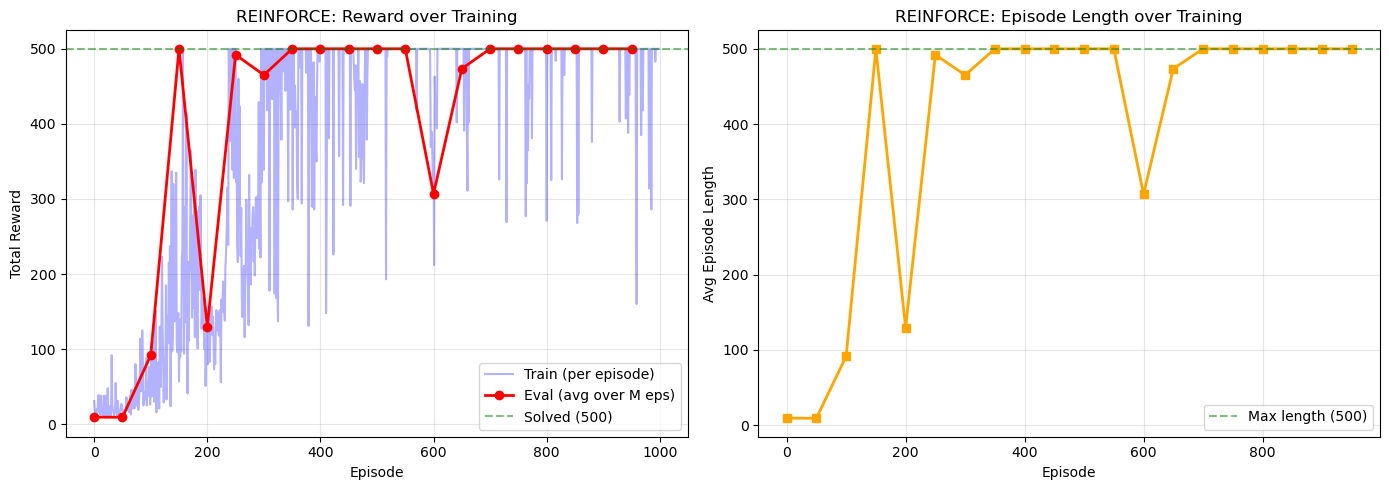

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **REINFORCE + standardizzazione, lr=3e-3:** sembra convergere più velocemente del caso lr=1e-2 e in modo più regolare. notiamo semore un calo a ep 200 ma possiamo notare come la reward subisca un calo praticamente dimezzato a ep 600 rispetto a quello avuto nel caso precedente. in generale sembra più robusto.

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [ ]:
policy = PolicyNetwork(state_dim=4, action_dim=2, hidden_dim=128).to(device)
critic = ValueNetwork(state_dim=4, hidden_dim=128).to(device) # <--- new value network for baseline


#Best LR: 1e-2


"""lr=3e-3,          
    value_lr=3e-3,  """


history = reinforce(
    policy=policy,
    env=env,
    value_net=critic,  
    lr=1e-2,          
    value_lr=1e-2,  
    gamma=cfg.training.gamma,
    num_episodes=cfg.training.num_episodes,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    device=cfg.training.device,
    use_standardize=False,   
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


⚠️  Value network provided but no optimizer specified. Defaulting to Adam.
[Ep    0] Train:   19.0 | Eval:    9.2
   💾 New best model saved!
[Ep   50] Train:   31.0 | Eval:   72.3
   💾 New best model saved!
[Ep  100] Train:   44.0 | Eval:  106.2
   💾 New best model saved!
[Ep  150] Train:  107.0 | Eval:  500.0
   💾 New best model saved!
[Ep  200] Train:  500.0 | Eval:  500.0
[Ep  250] Train:  500.0 | Eval:  500.0
[Ep  300] Train:  500.0 | Eval:  497.9
[Ep  350] Train:  500.0 | Eval:  500.0
[Ep  400] Train:  500.0 | Eval:  500.0
[Ep  450] Train:  500.0 | Eval:  500.0
[Ep  500] Train:  500.0 | Eval:  500.0
[Ep  550] Train:  500.0 | Eval:  500.0
[Ep  600] Train:  500.0 | Eval:  500.0
[Ep  650] Train:  500.0 | Eval:  500.0
[Ep  700] Train:  500.0 | Eval:  500.0
[Ep  750] Train:  500.0 | Eval:  500.0
[Ep  800] Train:  434.0 | Eval:  500.0
[Ep  850] Train:  500.0 | Eval:  500.0
[Ep  900] Train:  500.0 | Eval:  500.0
[Ep  950] Train:  500.0 | Eval:  500.0


eval/avg_length,▁▂▂█████████████████
eval/avg_reward,▁▂▂█████████████████
train/actor_loss,▅▆▆▄▅▅▄▇▄▆▅█▃▁▄▄▄▃▃▃▃▃▃▃▃▂▃▃▃▃▃▄▂▃▄▃▃▄▃▃
train/critic_loss,▁█▂▅▁▂▄▂▂▆▃▃▃▃▃▃▃▃▃▂▃▃▂▃▃▂▃▃▃▃▃▃▃▃▃▃▃▃▃▃
train/episode_reward,▁▂▂▂▂▂▆▇▇█▂█▇██████████████████████▆████
eval/avg_length,500
eval/avg_reward,500
train/actor_loss,0.22962
train/critic_loss,572.01898
train/episode_reward,500


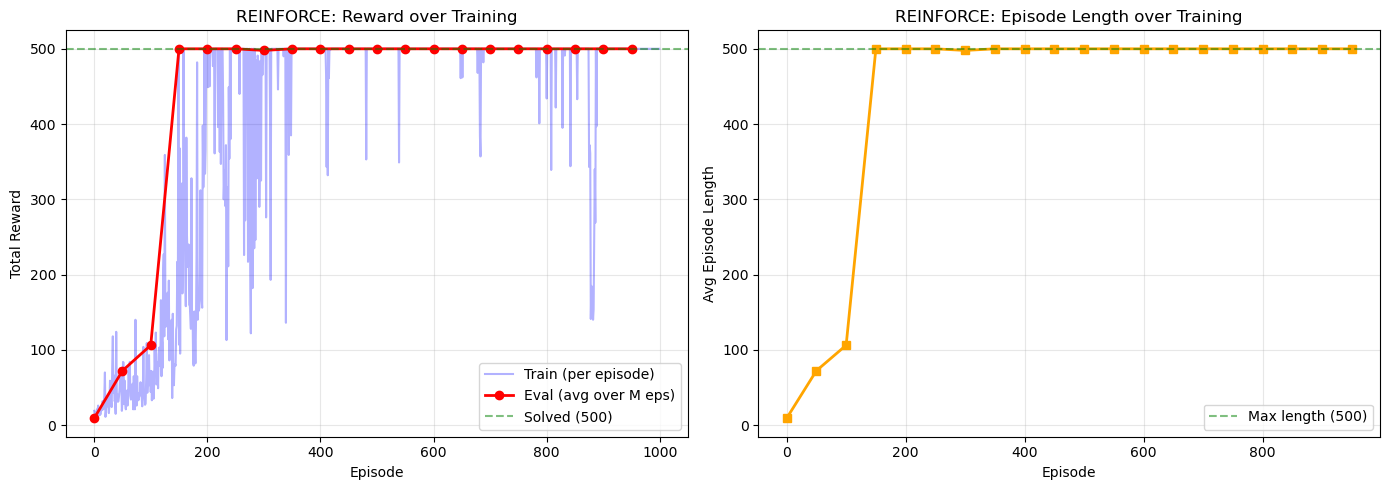

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **REINFORCE + value baseline (Actor-Critic):** convergenza al reward massimo già INTORNO all'episodio 150. Il critic impara V(s) e lo sottrae come baseline: gli advantages $G_t - V(s_t)$ indicano quanto un'azione è stata *migliore del previsto*, riducendo la varianza in modo state-dependent. 


-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 

## SCELTA ESERCIZIO: **Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)**

### IMPORTS

In [5]:
from drl_lab.networks import QNetwork
from drl_lab.algorithms import train_dqn
from drl_lab.buffer import ReplayBuffer
import omegaconf
from omegaconf import OmegaConf
import wandb

In [6]:
cfg = OmegaConf.load("config_dqn.yaml")

seed = 211
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device(cfg.training.device)

In [7]:
wandb.init(
    project=cfg.experiment.project,
    name=cfg.experiment.name,
    config=OmegaConf.to_container(cfg, resolve=True)
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/tomma/.netrc.
wandb: Currently logged in as: tommypasto (Tommy_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### **CARTPOLE** Enviroment

In [8]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=seed)
print(f"✅ Env created: {cfg.environment.name}")
print(f"   Observation Space: {env.observation_space.shape}")
print(f"   Action Space: {env.action_space}")

✅ Env created: CartPole-v1
   Observation Space: (4,)
   Action Space: Discrete(2)


In [9]:
import torch.optim as optim

q_net = QNetwork(
    state_dim=cfg.network.state_dim,
    action_dim=cfg.network.action_dim,
    hidden_dim=cfg.training.hidden_dim
).to(device)

target_q_net = QNetwork(
    state_dim=cfg.network.state_dim,
    action_dim=cfg.network.action_dim,
    hidden_dim=cfg.training.hidden_dim
).to(device)
target_q_net.load_state_dict(q_net.state_dict())
target_q_net.eval()

#optimizer = optim.Adam(q_net.parameters(), lr=cfg.training.lr)
optimizer = optim.AdamW(
    q_net.parameters(), 
    lr=1e-3         
    #weight_decay=1e-4  
)

buffer = ReplayBuffer(capacity=cfg.training.dqn_buffer_capacity)


print("✅ Reti e Buffer inizializzati")


✅ Reti e Buffer inizializzati


In [ ]:
history = train_dqn(
    q_net=q_net,
    target_q_net=target_q_net,
    env=env,
    optimizer=optimizer,
    buffer=buffer,
    gamma=cfg.training.gamma,
    total_steps=cfg.training.total_steps,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    epsilon_start=cfg.training.dqn_epsilon_start,
    epsilon_end=cfg.training.dqn_epsilon_end,
    epsilon_decay=cfg.training.dqn_epsilon_decay,
    learning_starts=cfg.training.dqn_learning_starts,
    batch_size=cfg.training.dqn_batch_size,
    use_huberLoss = False,   #NOTA: USO LA MSE poichè con Huberloss performava male
    gradient_clip_max_norm = 10.0,   #QUI proviamo con clipping con maxnorm a 10  
    device=cfg.training.device,
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

print("Training Completato!")

[Step   1000] Eval:   13.5 | Length: 13.5 | ε: 0.968
   💾 New best model saved!


/home/tomma/miniconda3/envs/rl_env/lib/python3.10/site-packages/gymnasium/envs/classic_control/cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


[Step   2000] Eval:  229.2 | Length: 229.2 | ε: 0.937
   💾 New best model saved!


/home/tomma/miniconda3/envs/rl_env/lib/python3.10/site-packages/gymnasium/envs/classic_control/cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


[Step   3000] Eval:  132.2 | Length: 132.2 | ε: 0.905
[Step   4000] Eval:  108.3 | Length: 108.3 | ε: 0.873
[Step   5000] Eval:   97.0 | Length: 97.0 | ε: 0.842
[Step   6000] Eval:   88.3 | Length: 88.3 | ε: 0.810
[Step   7000] Eval:   93.8 | Length: 93.8 | ε: 0.778
[Step   8000] Eval:  116.1 | Length: 116.1 | ε: 0.747
[Step   9000] Eval:   96.0 | Length: 96.0 | ε: 0.715
[Step  10000] Eval:   99.3 | Length: 99.3 | ε: 0.683
[Step  11000] Eval:   86.2 | Length: 86.2 | ε: 0.652
[Step  12000] Eval:   94.4 | Length: 94.4 | ε: 0.620
[Step  13000] Eval:   93.8 | Length: 93.8 | ε: 0.588
[Step  14000] Eval:  108.2 | Length: 108.2 | ε: 0.557
[Step  15000] Eval:  101.0 | Length: 101.0 | ε: 0.525
[Step  16000] Eval:   97.5 | Length: 97.5 | ε: 0.493
[Step  17000] Eval:  162.0 | Length: 162.0 | ε: 0.462
[Step  18000] Eval:  192.5 | Length: 192.5 | ε: 0.430
[Step  19000] Eval:  197.5 | Length: 197.5 | ε: 0.398
[Step  20000] Eval:  252.3 | Length: 252.3 | ε: 0.367
   💾 New best model saved!
[Step  210

eval/avg_length,▂▁▁▁▁▁▁▃▃▄▆███▁▃▂██▅▁██▅█▅▄███████▂███▁▃
eval/avg_reward,▁▂▂▂▄▃▄█▃▃▃█▆▂▄▂█████▆▄█▄██████████▇███▂
train/episode_reward,▁▁▁▂▁▁▁▁▁▂▁▁▁▁▂▁▂▁▁▁▁▂▁▁▂▁▁▂▄▇▁▃█▂▂▁▃▃█▆
train/epsilon,███████▇▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▂▂▂▁▁▁▁▁
train/loss,▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▂▃▄▂▁▁▁▁▂▇▂▁▇▂▂▁▇▁▁▇█▁▂
eval/avg_length,188.1
eval/avg_reward,188.1
train/episode_reward,464
train/epsilon,0.05
train/loss,1.69699


Training Completato!


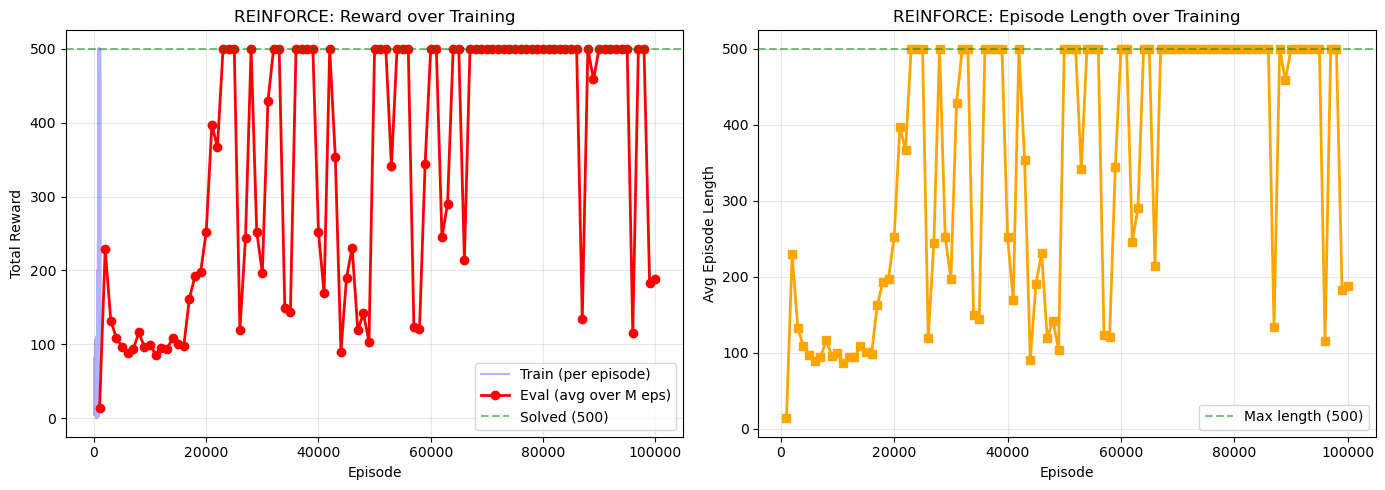

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# 2. Training
history = train_dqn(
    q_net=q_net,
    target_q_net=target_q_net,
    env=env,
    optimizer=optimizer,
    buffer=buffer,
    gamma=cfg.training.gamma,
    total_steps=cfg.training.total_steps,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    epsilon_start=cfg.training.dqn_epsilon_start,
    epsilon_end=cfg.training.dqn_epsilon_end,
    epsilon_decay=cfg.training.dqn_epsilon_decay,
    learning_starts=cfg.training.dqn_learning_starts,
    batch_size=cfg.training.dqn_batch_size,
    use_huberLoss = False,
    gradient_clip_max_norm = 100.0, #QUI proviamo con clipping con maxnorm a 100  
    device=cfg.training.device,
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

print("Training Completato!")

[Step   1000] Eval:    9.3 | Length: 9.3 | ε: 0.968
   💾 New best model saved!


/home/tomma/miniconda3/envs/rl_env/lib/python3.10/site-packages/gymnasium/envs/classic_control/cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


[Step   2000] Eval:  167.4 | Length: 167.4 | ε: 0.937
   💾 New best model saved!


/home/tomma/miniconda3/envs/rl_env/lib/python3.10/site-packages/gymnasium/envs/classic_control/cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


[Step   3000] Eval:  142.4 | Length: 142.4 | ε: 0.905
[Step   4000] Eval:  174.6 | Length: 174.6 | ε: 0.873
   💾 New best model saved!
[Step   5000] Eval:   57.0 | Length: 57.0 | ε: 0.842
[Step   6000] Eval:   81.6 | Length: 81.6 | ε: 0.810
[Step   7000] Eval:   96.7 | Length: 96.7 | ε: 0.778
[Step   8000] Eval:   99.2 | Length: 99.2 | ε: 0.747
[Step   9000] Eval:  126.6 | Length: 126.6 | ε: 0.715
[Step  10000] Eval:  114.7 | Length: 114.7 | ε: 0.683
[Step  11000] Eval:  111.6 | Length: 111.6 | ε: 0.652
[Step  12000] Eval:  131.4 | Length: 131.4 | ε: 0.620
[Step  13000] Eval:  130.3 | Length: 130.3 | ε: 0.588
[Step  14000] Eval:  115.9 | Length: 115.9 | ε: 0.557
[Step  15000] Eval:  175.9 | Length: 175.9 | ε: 0.525
   💾 New best model saved!
[Step  16000] Eval:  143.0 | Length: 143.0 | ε: 0.493
[Step  17000] Eval:  169.5 | Length: 169.5 | ε: 0.462
[Step  18000] Eval:  122.0 | Length: 122.0 | ε: 0.430
[Step  19000] Eval:  111.2 | Length: 111.2 | ε: 0.398
[Step  20000] Eval:  201.2 | Len

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7c20f2b333a0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7c20f1f4e8c0, execution_count=9 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7c20f1f4ed10, raw_cell="
# 2. Training
history = train_dqn(
    q_net=q_ne.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tomma/DLA/Assignment3/dla-lab3_prova.ipynb#Y104sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

### **DQN su CartPole (training interrotto a ~107k steps):** anche con training incompleto si vede la convergenza tipica di DQN: fase esplorativa con ε alto e reward basso, poi miglioramento rapido non appena il buffer è sufficientemente popolato e ε scende. Il soft update del target network (τ=0.005) garantisce aggiornamenti stabili evitando le oscillazioni dell'hard update periodico.

In [ ]:
history

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training rewards (per episode) vs Evaluation rewards (every N episodes)
ax1.plot(history["train_rewards"], alpha=0.3, label="Train (per episode)", color="blue")
ax1.plot(history["eval_episodes"], history["eval_rewards"],
         marker="o", label="Eval (avg over M eps)", color="red", linewidth=2)
ax1.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Solved (500)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.set_title("REINFORCE: Reward over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Evaluation episode lengths
ax2.plot(history["eval_episodes"], history["eval_lengths"],
         marker="s", color="orange", linewidth=2)
ax2.axhline(y=500, color="green", linestyle="--", alpha=0.5, label="Max length (500)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg Episode Length")
ax2.set_title("REINFORCE: Episode Length over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **LUNAR LANDER** Enviroment

In [ ]:
env = gym.make("LunarLander-v3")

obs, _ = env.reset(seed=seed)
print(f"✅ Ambiente creato: {cfg.environment.name}")
print(f"   Observation Space: {env.observation_space.shape}")
print(f"   Action Space: {env.action_space}")

✅ Ambiente creato: LunarLander-v3
   Observation Space: (8,)
   Action Space: Discrete(4)


In [6]:
import torch.optim as optim

q_net = QNetwork(
    state_dim=cfg.network.state_dim,
    action_dim=cfg.network.action_dim,
    hidden_dim=cfg.training.hidden_dim
).to(device)

target_q_net = QNetwork(
    state_dim=cfg.network.state_dim,
    action_dim=cfg.network.action_dim,
    hidden_dim=cfg.training.hidden_dim
).to(device)
target_q_net.load_state_dict(q_net.state_dict())
target_q_net.eval()

#optimizer = optim.Adam(q_net.parameters(), lr=cfg.training.lr)
optimizer = optim.AdamW(
    q_net.parameters(), 
    lr=1e-3         
    #weight_decay=1e-4  
)

buffer = ReplayBuffer(capacity=cfg.training.dqn_buffer_capacity)


print("✅ Reti e Buffer inizializzati")


✅ Reti e Buffer inizializzati


In [ ]:

# 2. Training
history = train_dqn(
    q_net=q_net,
    target_q_net=target_q_net,
    env=env,
    optimizer=optimizer,
    buffer=buffer,
    gamma=cfg.training.gamma,
    total_steps=cfg.training.total_steps,
    eval_freq=cfg.training.eval_freq,
    eval_episodes=cfg.training.eval_episodes,
    epsilon_start=cfg.training.dqn_epsilon_start,
    epsilon_end=cfg.training.dqn_epsilon_end,
    epsilon_decay=cfg.training.dqn_epsilon_decay,
    learning_starts=cfg.training.dqn_learning_starts,
    batch_size=cfg.training.dqn_batch_size,
    use_huberLoss = True,
    gradient_clip_max_norm = 100.0,
    device=cfg.training.device,
    use_wandb=cfg.logging.use_wandb,
    checkpoint_dir=cfg.logging.checkpoint_dir
)

env.close()

print("Training Completato!")

[Step   1000] Eval: -296.0 | Length: 72.4 | ε: 0.968
   💾 New best model saved!
[Step   2000] Eval: -112.7 | Length: 1000.0 | ε: 0.937
   💾 New best model saved!
[Step   3000] Eval: -163.6 | Length: 862.0 | ε: 0.905
[Step   4000] Eval: -144.5 | Length: 1000.0 | ε: 0.873
[Step   5000] Eval: -139.8 | Length: 1000.0 | ε: 0.842
[Step   6000] Eval: -125.7 | Length: 1000.0 | ε: 0.810
[Step   7000] Eval: -112.8 | Length: 914.1 | ε: 0.778
[Step   8000] Eval: -122.9 | Length: 749.4 | ε: 0.747
[Step   9000] Eval: -152.9 | Length: 882.3 | ε: 0.715
[Step  10000] Eval: -171.6 | Length: 895.9 | ε: 0.683
[Step  11000] Eval:  -59.6 | Length: 1000.0 | ε: 0.652
   💾 New best model saved!
[Step  12000] Eval:  -64.1 | Length: 1000.0 | ε: 0.620
[Step  13000] Eval: -230.8 | Length: 988.1 | ε: 0.588
[Step  14000] Eval: -295.0 | Length: 849.5 | ε: 0.557
[Step  15000] Eval: -730.0 | Length: 838.4 | ε: 0.525
[Step  16000] Eval: -787.2 | Length: 446.5 | ε: 0.493
[Step  17000] Eval: -586.2 | Length: 657.1 | ε: 0.

eval/avg_length,██▇▇▃█▆▃▆▅▃▅▄▃▂▂▂▂▂▄▃▄▇▂▂▂▅▄▁▃▃▇▂▂▂▂▅▁▂▂
eval/avg_reward,▅▆▁▆▆▆▇▇█▇▇█▇███▇███████████████▇█▇█████
train/episode_reward,▃▃▃▂▁▂▁▃▃▄▃▄▃▄▄▄▄▇▅▅▆▅▅▅███▇▆▁▇█▆███▇▇█▄
train/epsilon,█▇▇▆▆▆▅▅▅▅▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▆▃▃▃▆▆▃▄▃█▆▅▃▄▃▂▂▂▃▂▄▁▃▃▂▂▃▂▁▂▂▄▃▃▁▃▂▁▁▁
eval/avg_length,322.4
eval/avg_reward,242.93306
train/episode_reward,306.95873
train/epsilon,0.05
train/loss,0.27396


Training Completato!


### **DQN su LunarLander (200k steps):** LunarLander ha osservazioni a 8 dimensioni e 4 azioni, ed è significativamente più difficile di CartPole. Nelle prime fasi il reward è fortemente negativo (crash frequenti, length 1000 = episodio troncato per timeout). La convergenza è più lenta ma il modello impara a evitare i crash, come confermato dalla riduzione progressiva della episode length e dal miglioramento del reward verso valori positivi nelle ultime iterazioni.

In [ ]:

import torch
import gymnasium as gym

# 1. Read dimensions from the environment
env = gym.make("LunarLander-v3")
# = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]   # 8
action_dim = env.action_space.n              # 4
env.close()

# 2. Istantiate Q-net with HIDDEN_DIM=258 (from checkpoint)
q_net = QNetwork(state_dim=state_dim, action_dim=action_dim, hidden_dim=258)

# 3. loads checkpoint
checkpoint_path = "checkpoints/best_q_net.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")
q_net.load_state_dict(checkpoint['q_net_state_dict'])
q_net.eval()

print(f"✅ Caricato step {checkpoint.get('step', '?')}, reward {checkpoint.get('reward', '?')}")

# --- 4. play  ---
def play_visual(q_net, env_name="LunarLander-v3", episodes=5, device="cpu", sleep_time=0.02):
    env = gym.make(env_name, render_mode="human")
    q_net.eval()
    
    for ep in range(episodes):
        obs, _ = env.reset()
        episode_reward = 0.0
        episode_length = 0
        done = False
        
        print(f"\n🎬 Episodio {ep + 1}/{episodes}")
        
        while not done:
            with torch.no_grad():
                obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
                action = q_net(obs_tensor).argmax(dim=-1).item()
            
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            episode_length += 1
            
            import time
            time.sleep(sleep_time)
        
        print(f"   Reward: {episode_reward:.1f} | Length: {episode_length}")
    
    env.close()
    print("\n🏁 Fine")

# Start
play_visual(q_net, episodes=5, sleep_time=0.02)